<a href="https://colab.research.google.com/github/Avinash01715/ds-ml-projects/blob/main/Random%20Forest/random_forest_sweep_sonar_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Learnings:**
1. Random Forest beats a single tree by averaging out noise.

2. More trees have a ceiling, and past it, more can mean worse.

3. Cost(training time) scales linearly even when benefit doesn't.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [33]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [34]:
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [35]:
X = df.iloc[:, :-1].values
y = (df.iloc[:, -1] == 'R').astype(int).values

train test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

**Random forest sweep**

In [37]:
tree_counts = [1, 10, 50, 100, 200, 500, 1000]
results = []

for n in tree_counts:
    start = time.time()
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)
    total_time = time.time() - start
    test_acc = accuracy_score(y_test, rf_model.predict(X_test))
    results.append((n, test_acc, total_time))
    print(f"n_estimators={n}: Test={test_acc:.4f} Time={total_time:.3f}s")

n_estimators=1: Test=0.6667 Time=0.007s
n_estimators=10: Test=0.7619 Time=0.025s
n_estimators=50: Test=0.8413 Time=0.105s
n_estimators=100: Test=0.8571 Time=0.204s
n_estimators=200: Test=0.8413 Time=0.391s
n_estimators=500: Test=0.8254 Time=0.968s
n_estimators=1000: Test=0.8254 Time=1.940s


**Curve plotting**

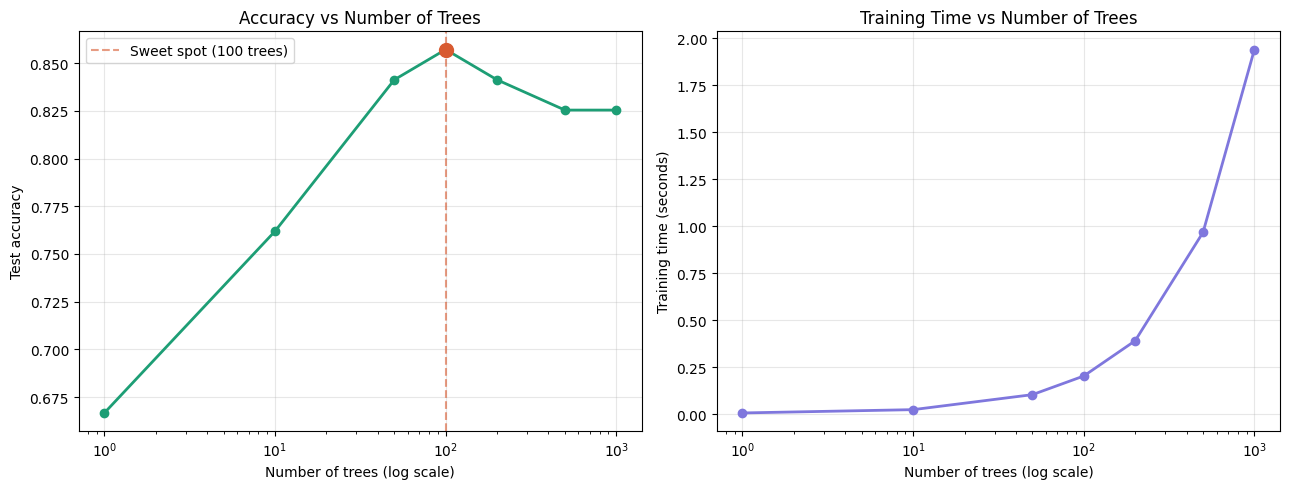

In [38]:
tree_counts = [r[0] for r in results]
test_accs = [r[1] for r in results]
train_times = [r[2] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# accuracy vs tree count
ax1.plot(tree_counts, test_accs, marker='o', linewidth=2, color='#1D9E75')
ax1.set_xscale('log')
ax1.set_xlabel('Number of trees (log scale)')
ax1.set_ylabel('Test accuracy')
ax1.set_title('Accuracy vs Number of Trees')
ax1.axvline(100, color='#D85A30', linestyle='--', alpha=0.6, label='Sweet spot (100 trees)')
ax1.scatter([100], [0.8571], color='#D85A30', s=100, zorder=5)
ax1.legend()
ax1.grid(alpha=0.3)

# training time
ax2.plot(tree_counts, train_times, marker='o', linewidth=2, color='#7F77DD')
ax2.set_xscale('log')
ax2.set_xlabel('Number of trees (log scale)')
ax2.set_ylabel('Training time (seconds)')
ax2.set_title('Training Time vs Number of Trees')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rf_model_learning_curve.png', dpi=150)